In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

import healpy as hp
from scipy import stats
from IPython.display import Image

sys.path.append(os.path.expanduser('~/git/desi-targets/useful'))
from isdes import get_isdes

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

plt.rcParams['image.cmap'] = 'seismic'

In [3]:
randoms_counts_dir = '/Users/rongpu/Documents/Data/desi_targets/dr9.0/imaging_systematics/randoms_stats/0.49.0/resolve/counts'
randoms_systematics_dir = '/Users/rongpu/Documents/Data/desi_targets/dr9.0/imaging_systematics/randoms_stats/0.49.0/resolve/systematics'
target_densities_dir = '/Users/rongpu/Documents/Data/desi_targets/dr9.0/imaging_systematics/density_maps/1.0.0/resolve'

top_plot_dir = '/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve'

min_nobs = 1
maskbits_dict = {'LRG': [1, 8, 9, 11, 12, 13], 'ELG': [1, 11, 12, 13], 'QSO': [1, 8, 9, 11, 12, 13], 'BGS_ANY': [1, 13], 'BGS_BRIGHT': [1, 13]}

min_pix_frac = 0.4  # minimum fraction of pixel area to be used

In [4]:
error_of_the_mean = lambda x: np.std(x)/np.sqrt(len(x))

def binned_mean(x, y, bin_edges=None, weights=None, minsize=30, nbins=30, percentiles=[0.5, 99.5]):
    if bin_edges is None:
        vmin, vmax = np.percentile(x, percentiles)
        bin_edges = np.linspace(vmin, vmax, nbins)
    if weights is None:
        weights = np.ones(len(x))
    bin_mean = np.zeros(len(bin_edges)-1)
    for index in range(len(bin_edges)-1):
        mask = (x>bin_edges[index]) & (x<=bin_edges[index+1])
        if np.sum(mask)<minsize:
            bin_mean[index]=np.nan
        else:
            bin_mean[index] = np.sum(y[mask]*weights[mask])/np.sum(weights[mask])    
    bin_error, _, _ = stats.binned_statistic(x, y, statistic=error_of_the_mean, bins=bin_edges)
    bin_error[np.isnan(bin_mean)] = np.nan
    bin_center = (bin_edges[1:] + bin_edges[:-1])/2
    
    return bin_center, bin_edges, bin_mean, bin_error

In [5]:
var_range_qso = 0.25
var_range_notqso = 0.15

xnames_notqso = ['stardens', 'EBV', 'psfdepth_w1mag', 'galdepth_gmag', 'galdepth_rmag', 'galdepth_zmag', 'PSFSIZE_G', 'PSFSIZE_R', 'PSFSIZE_Z']
xlabels_notqso = ['GAIA stellar density [deg$^{-2}$]', 'E(B-V)', 'W1-band PSF depth [mag]', 'g-band galaxy depth [mag]', 'r-band galaxy depth [mag]', 'z-band galaxy depth [mag]', 'g-band PSF size [arcsec]', 'r-band PSF size [arcsec]', 'z-band PSF size [arcsec]', ]
xlabels_ebv_notqso = ['GAIA stellar density [deg$^{-2}$]', 'E(B-V)', 'W1-band PSF depth - 0.184*E(B-V) [mag]', 'g-band galaxy depth - 3.214*E(B-V) [mag]', 'r-band galaxy depth - 2.165*E(B-V) [mag]', 'z-band galaxy depth - 1.211*E(B-V) [mag]', 'g-band PSF size [arcsec]', 'r-band PSF size [arcsec]', 'z-band PSF size [arcsec]', ]

# Add W2 depth for QSOs
xnames_qso = ['stardens', 'EBV', 'psfdepth_w1mag', 'psfdepth_w2mag', 'psfdepth_gmag', 'psfdepth_rmag', 'psfdepth_zmag', 'PSFSIZE_G', 'PSFSIZE_R', 'PSFSIZE_Z']
xlabels_qso = ['GAIA stellar density [deg$^{-2}$]', 'E(B-V)', 'W1-band PSF depth [mag]', 'W2-band PSF depth', 'g-band PSF depth [mag]', 'r-band PSF depth [mag]', 'z-band PSF depth [mag]', 'g-band PSF size [arcsec]', 'r-band PSF size [arcsec]', 'z-band PSF size [arcsec]']
xlabels_ebv_qso = ['GAIA stellar density [deg$^{-2}$]', 'E(B-V)', 'W1-band PSF depth - 0.184*E(B-V) [mag]', 'W2-band PSF depth - 0.184*E(B-V) [mag]', 'g-band PSF depth - 3.214*E(B-V) [mag]', 'r-band PSF depth - 2.165*E(B-V) [mag]', 'z-band PSF depth - 1.211*E(B-V) [mag]', 'g-band PSF size [arcsec]', 'r-band PSF size [arcsec]', 'z-band PSF size [arcsec]']

bin_params = {}
bin_params['stardens'], bin_params['stardens_nbins'] = np.array([200, 3500]), 50
bin_params['stardens_log'], bin_params['stardens_log_nbins'] = np.array([2.3, 3.6]), 50
bin_params['EBV'], bin_params['EBV_nbins'] = np.array([0., 0.15]), 50
bin_params['galdepth_gmag'], bin_params['galdepth_gmag_nbins'] = np.array([23.85, 25.3]), 60
bin_params['galdepth_rmag'], bin_params['galdepth_rmag_nbins'] = np.array([23.2, 25.]), 60
bin_params['galdepth_zmag'], bin_params['galdepth_zmag_nbins'] = np.array([22.6, 23.75]), 60
bin_params['psfdepth_gmag'], bin_params['psfdepth_gmag_nbins'] = np.array([23.85+0.15, 25.3+0.35]), 60
bin_params['psfdepth_rmag'], bin_params['psfdepth_rmag_nbins'] = np.array([23.2+0.2, 25.+0.4]), 60
bin_params['psfdepth_zmag'], bin_params['psfdepth_zmag_nbins'] = np.array([22.6+0.2, 23.75+0.4]), 60
bin_params['psfdepth_w1mag'], bin_params['psfdepth_w1mag_nbins'] = np.array([21.2, 22.]), 50
bin_params['psfdepth_w2mag'], bin_params['psfdepth_w2mag_nbins'] = np.array([20.5, 21.8]), 50
bin_params['PSFSIZE_G'], bin_params['PSFSIZE_G_nbins'] = np.array([1.1, 2.5]), 50
bin_params['PSFSIZE_R'], bin_params['PSFSIZE_R_nbins'] = np.array([1.0, 2.3]), 50
bin_params['PSFSIZE_Z'], bin_params['PSFSIZE_Z_nbins'] = np.array([0.9, 1.9]), 50
bin_params['galdepth_gmag_ebv'], bin_params['galdepth_gmag_ebv_nbins'] = bin_params['galdepth_gmag'] - 0.1, 60
bin_params['galdepth_rmag_ebv'], bin_params['galdepth_rmag_ebv_nbins'] = bin_params['galdepth_rmag'] - 0.1, 60
bin_params['galdepth_zmag_ebv'], bin_params['galdepth_zmag_ebv_nbins'] = bin_params['galdepth_zmag'] - 0.05, 60
bin_params['psfdepth_w1mag_ebv'], bin_params['psfdepth_w1mag_ebv_nbins'] = bin_params['psfdepth_w1mag'], 60
bin_params['psfdepth_w2mag_ebv'], bin_params['psfdepth_w2mag_ebv_nbins'] = bin_params['psfdepth_w2mag'], 60
bin_params['psfdepth_gmag_ebv'], bin_params['psfdepth_gmag_ebv_nbins'] = bin_params['psfdepth_gmag'] - 0.1, 60
bin_params['psfdepth_rmag_ebv'], bin_params['psfdepth_rmag_ebv_nbins'] = bin_params['psfdepth_rmag'] - 0.1, 60
bin_params['psfdepth_zmag_ebv'], bin_params['psfdepth_zmag_ebv_nbins'] = bin_params['psfdepth_zmag'] - 0.05, 60
bin_params['psfdepth_w1mag_ebv'], bin_params['psfdepth_w1mag_ebv_nbins'] = bin_params['psfdepth_w1mag'], 50
bin_params['psfdepth_w2mag_ebv'], bin_params['psfdepth_w2mag_ebv_nbins'] = bin_params['psfdepth_w2mag'], 50

------
## Separate DES and DECaLS footprints

In [6]:
for target_class in ['BGS_ANY', 'BGS_BRIGHT', 'LRG', 'ELG', 'QSO']:
    
    print(target_class)
    target_class = target_class.lower()

    if target_class=='qso':
        xnames, xlabels, xlabels_ebv, var_range = xnames_qso, xlabels_qso, xlabels_ebv_qso, var_range_qso
    else:
        xnames, xlabels, xlabels_ebv, var_range = xnames_notqso, xlabels_notqso, xlabels_ebv_notqso, var_range_notqso

    maskbits = maskbits_dict[target_class.upper()]

    for nside in [64, 128, 256, 512]:

        print('NSIDE = {}'.format(nside))

        npix = hp.nside2npix(nside)
        pix_area = hp.pixelfunc.nside2pixarea(nside, degrees=True)
        print('Healpix size = {:.5f} sq deg'.format(pix_area))

        maps_dict = {}

        for region in ['BASS+MzLS', 'DECaLS', 'DES']:

            if region=='BASS+MzLS':
                field = 'north'
            else:
                field = 'south'

            density = Table.read(os.path.join(target_densities_dir, 'density_map_{}_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(target_class, field, nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))
            maps = Table.read(os.path.join(randoms_counts_dir, 'counts_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(field, nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))
            maps = maps[maps['n_randoms']>0]
            maps1 = Table.read(os.path.join(randoms_systematics_dir, 'systematics_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(field, nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))
            maps1.remove_columns(['RA', 'DEC'])
            maps = join(maps, maps1, join_type='inner', keys='HPXPIXEL')
            maps = join(maps, density[['HPXPIXEL', 'n_targets']], join_type='outer', keys='HPXPIXEL').filled(0)

            mask = maps['FRACAREA']>min_pix_frac
            maps = maps[mask]
            mask = maps['DEC']>-30  # Remove the southern part of DES
            maps = maps[mask]
            maps['density'] = maps['n_targets'] / (pix_area * maps['FRACAREA'])

            # Load stellar density map
            stardens = np.load('/Users/rongpu/Documents/Data/desi_lrg_selection/dr7/healpix_maps/pixweight-dr7.1-0.22.0_stardens_{}_ring.npy'.format(nside))
            maps['stardens'] = stardens[maps['HPXPIXEL']]
            maps['stardens_log'] = np.log10(maps['stardens'])

            if field=='south':
                isdes = get_isdes(maps['RA'], maps['DEC'], nside)
                if region=='DES':
                    maps = maps[isdes]
                else:
                    maps = maps[~isdes]

            maps_dict[region] = maps.copy()

        # Combine the maps just to get the average density
        mask = (maps_dict['BASS+MzLS']['DEC']>32.375)
        mask1 = ~np.in1d(maps_dict['DECaLS']['HPXPIXEL'], maps_dict['BASS+MzLS']['HPXPIXEL'][mask])
        maps_combine = vstack([maps_dict['BASS+MzLS'][mask], maps_dict['DECaLS'][mask1], maps_dict['DES']]).copy()

        area = np.sum(maps_combine['FRACAREA'])*pix_area
        mean_density = np.sum(maps_combine['n_targets'])/area
        print('Total area = {:.1f} sq deg'.format(area))
        print('Average density: {:.1f} (per square degree)'.format(mean_density))

        ########################################################################################################

        if nside>=512:
            minsize = 400
        elif nside==256:
            minsize = 100
        else:
            minsize = 50

        plot_dir = os.path.join(top_plot_dir, '{}_minobs_{}_maskbits_{}'.format(target_class, min_nobs, ''.join([str(tmp) for tmp in maskbits])))
        if not os.path.isdir(plot_dir):
            os.makedirs(plot_dir)

        for ebv_corr in [False, True]:

            for index, xname in enumerate(xnames):

                if ebv_corr and ('depth' in xname):
                    xname += '_ebv'
                    xlabel = xlabels_ebv[index]
                else:
                    xlabel = xlabels[index]

                bin_edges = np.linspace(*bin_params[xname], bin_params[xname+'_nbins'])

                bin_width = bin_edges[1]-bin_edges[0]
                histbin_edge = np.arange(bin_edges[0] - 2*bin_width, bin_edges[-1] + 2.1*bin_width, bin_width)
                xmin, xmax = bin_edges[0] - 2*bin_width, bin_edges[-1] + 2*bin_width

                # normalize the histograms to the histogram of the full sample
                bincount_max = np.max([np.histogram(maps_dict[region][xname], bins=histbin_edge)[0].max() for region in ['BASS+MzLS', 'DECaLS', 'DES']])

                fig, ax = plt.subplots(figsize=(5.8, 4))

                for region, color in zip(['BASS+MzLS', 'DECaLS', 'DES'], ['C1', 'C0', 'C2']):

                    maps_mask = np.ones(len(maps_dict[region]), dtype=bool)
                    bin_center, _, bin_mean, bin_error = binned_mean(maps_dict[region][xname][maps_mask], maps_dict[region]['density'][maps_mask]/mean_density, bin_edges=bin_edges, weights=maps_dict[region]['FRACAREA'][maps_mask], minsize=minsize)
                    histbin_center = (histbin_edge[1:]+histbin_edge[:-1])/2
                    bincount, _ = np.histogram(maps_dict[region][xname][maps_mask], bins=histbin_edge)
                    bincount = 0.8*var_range*bincount/bincount_max
                    ax.errorbar(bin_center, bin_mean-1, yerr=bin_error, label=region, color=color)
                    ax.hist(histbin_center, bins=histbin_edge, weights=bincount, alpha=0.3, color=color)

                ax.grid(alpha=0.5)
                ax.set_xlabel(xlabel)
                ax.set_ylabel(r'$N_\mathrm{gal}\ /\ \overline{N}_\mathrm{gal} - 1$')
                ax.axis([xmin, xmax, -var_range, var_range])
                if index==len(xnames)-1:
                    plt.legend(loc='upper right')
                plt.tight_layout()
                plt.savefig('tmp/{}_{}.png'.format(target_class, index+1))
                plt.close()

            if ebv_corr:
                plot_dir_path = os.path.join(plot_dir, 'systematics_{}_{}_ebv_corr.png'.format(target_class, nside))
            else:
                plot_dir_path = os.path.join(plot_dir, 'systematics_{}_{}.png'.format(target_class, nside))
            print(plot_dir_path)

            if target_class=='qso':
                os.system('montage tmp/{}_{{1..7}}.png null: tmp/{}_{{8..{}}}.png -geometry 100% -tile 4x {}'.format(target_class, target_class, len(xnames), plot_dir_path))
            else:
                os.system('montage tmp/{}_{{1..{}}}.png -geometry 100% -tile 3x {}'.format(target_class, len(xnames), plot_dir_path))
            # Image(plot_dir_path)
        print()
    print()

BGS_ANY
NSIDE = 64
Healpix size = 0.83929 sq deg
Total area = 16280.1 sq deg
Average density: 1397.5 (per square degree)
/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/bgs_any_minobs_1_maskbits_113/systematics_bgs_any_64.png
/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/bgs_any_minobs_1_maskbits_113/systematics_bgs_any_64_ebv_corr.png

NSIDE = 128
Healpix size = 0.20982 sq deg
Total area = 16339.0 sq deg
Average density: 1397.5 (per square degree)
/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/bgs_any_minobs_1_maskbits_113/systematics_bgs_any_128.png
/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/bgs_any_minobs_1_maskbits_113/systematics_bgs_any_128_ebv_corr.png

NSIDE = 256
Healpix size = 0.05246 sq deg
Total area = 16373.2 sq deg
Average density: 1397.4 (per square degree)
/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/

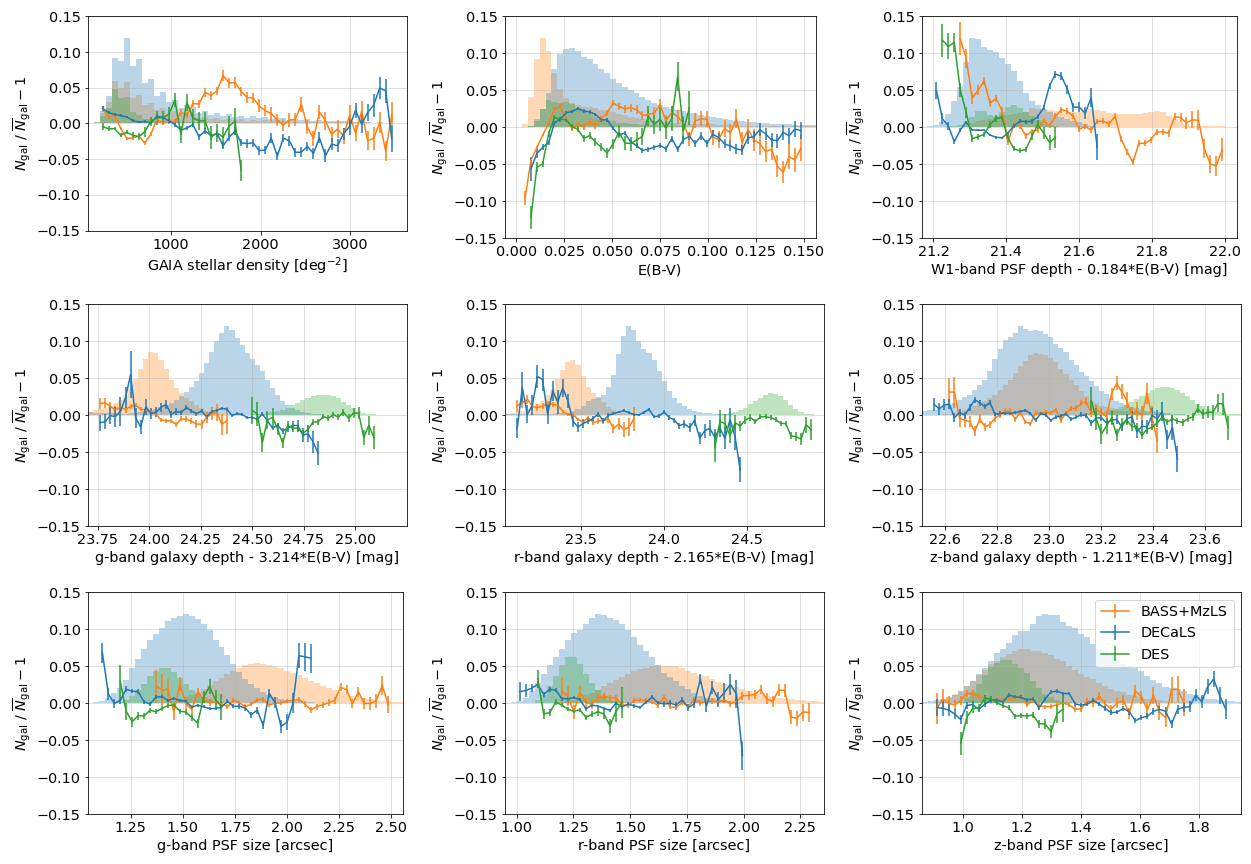

In [7]:
# BGS_ANY
Image('/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/bgs_any_minobs_1_maskbits_113/systematics_bgs_any_512_ebv_corr.png')

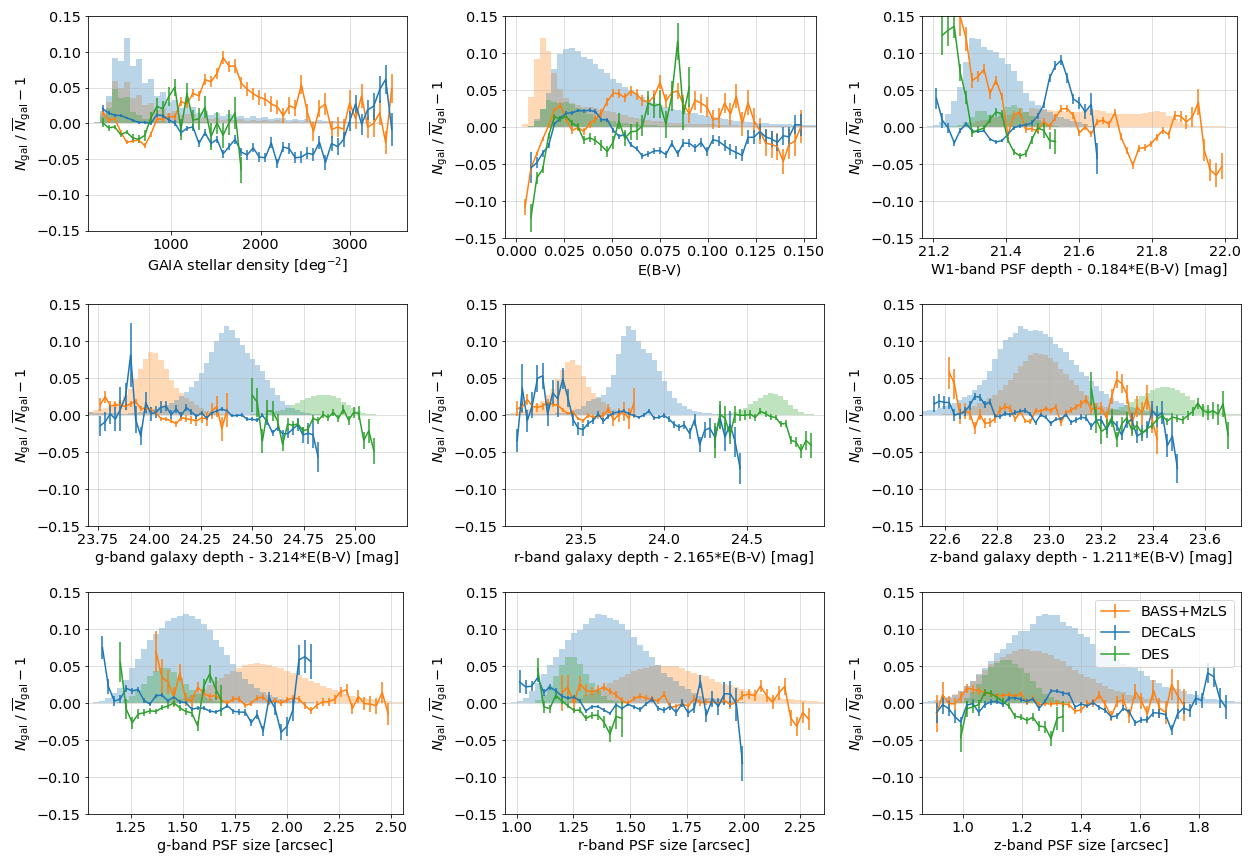

In [8]:
# BGS_BRIGHT
Image('/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/bgs_bright_minobs_1_maskbits_113/systematics_bgs_bright_512_ebv_corr.png')

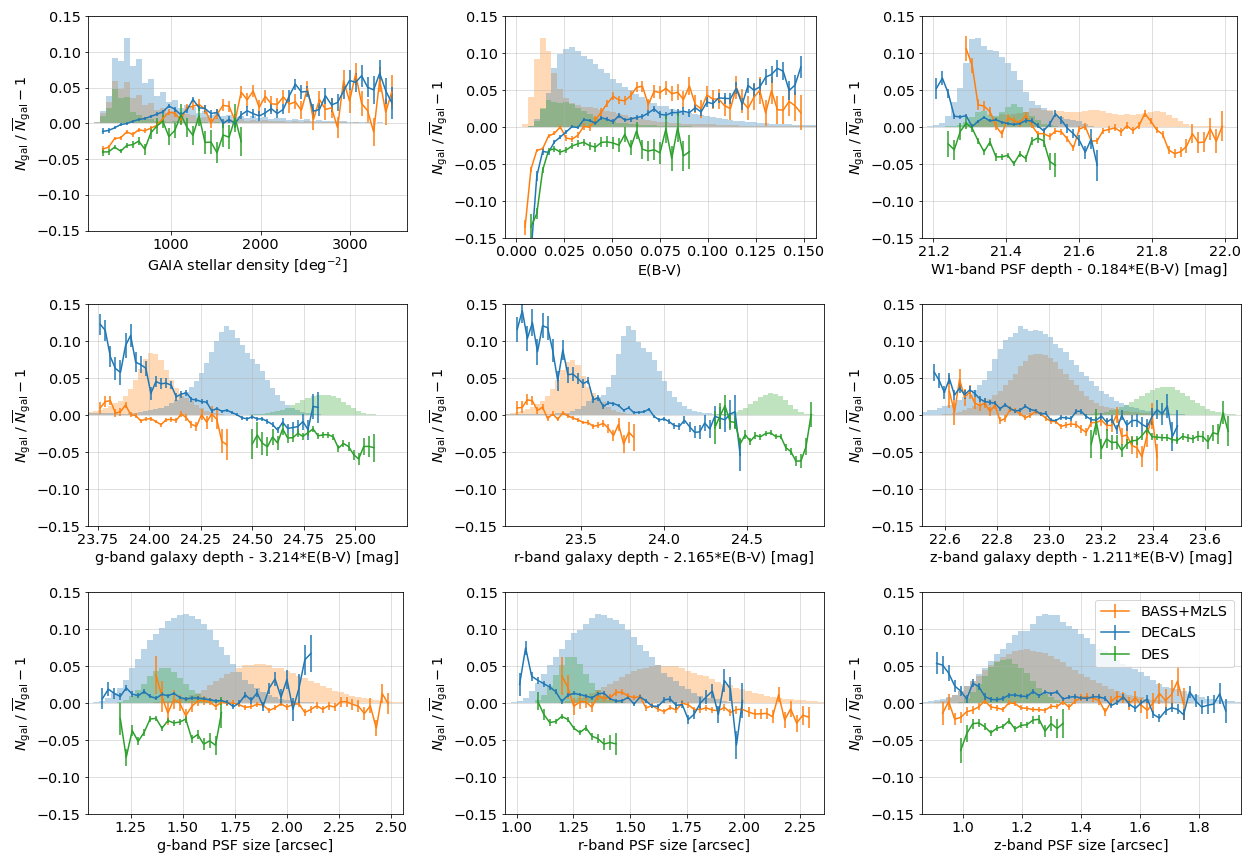

In [9]:
# LRG
Image('/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/lrg_minobs_1_maskbits_189111213/systematics_lrg_512_ebv_corr.png')

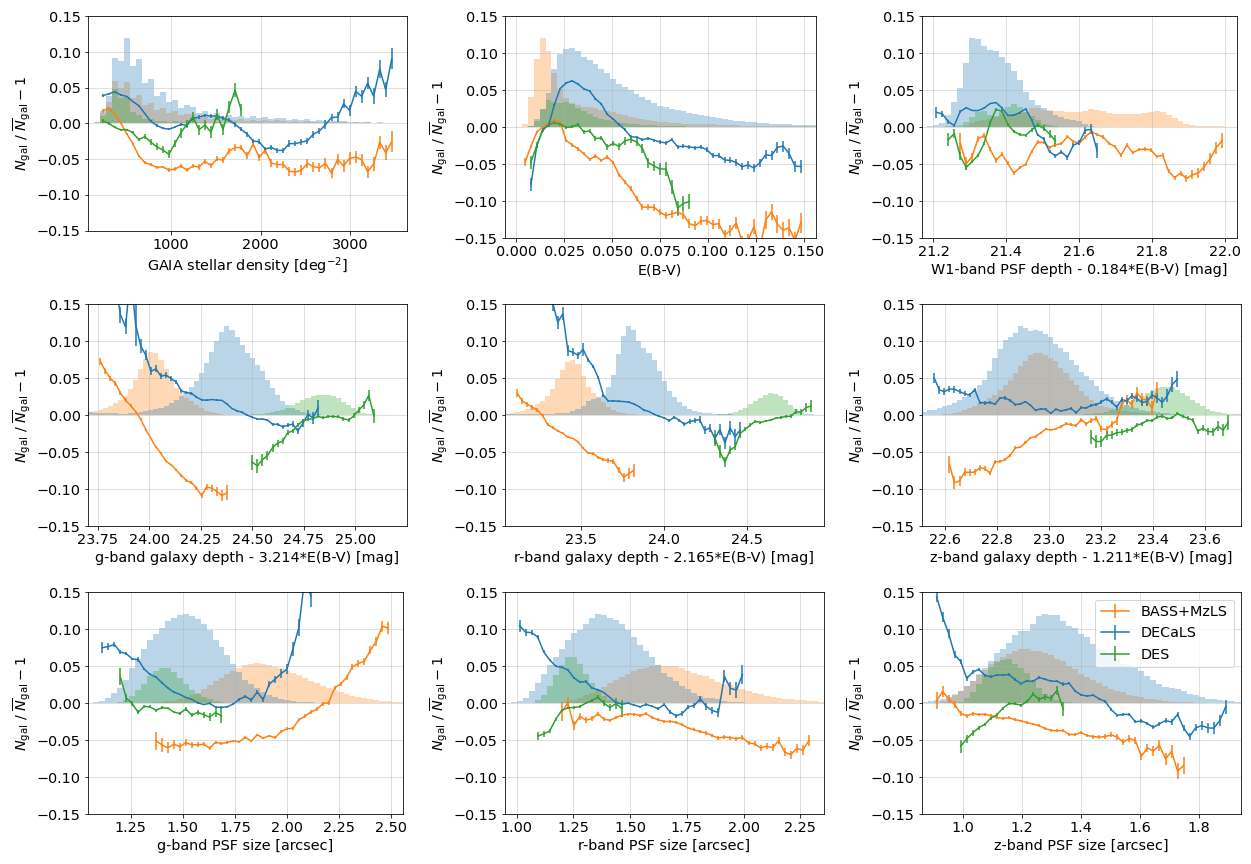

In [10]:
# ELG
Image('/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/elg_minobs_1_maskbits_1111213/systematics_elg_512_ebv_corr.png')

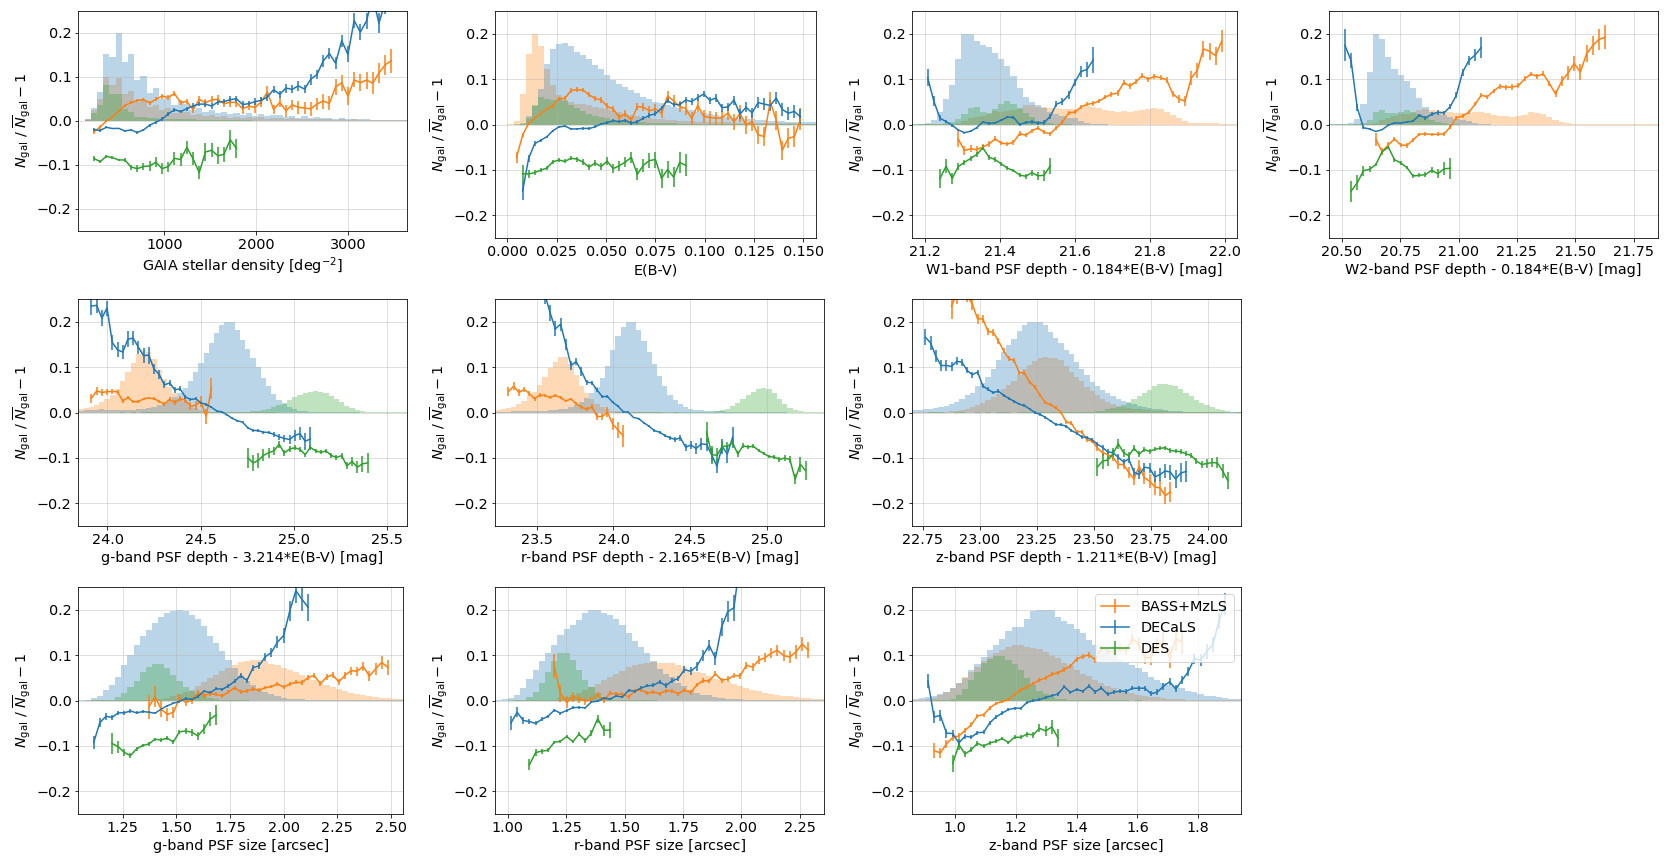

In [11]:
# QSO
Image('/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/qso_minobs_1_maskbits_189111213/systematics_qso_512_ebv_corr.png')

------
## NOT Separating DES and DECaLS footprints

In [12]:
for target_class in ['BGS_ANY', 'BGS_BRIGHT', 'LRG', 'ELG', 'QSO']:

    print(target_class)
    target_class = target_class.lower()

    if target_class=='qso':
        xnames, xlabels, xlabels_ebv, var_range = xnames_qso, xlabels_qso, xlabels_ebv_qso, var_range_qso
    else:
        xnames, xlabels, xlabels_ebv, var_range = xnames_notqso, xlabels_notqso, xlabels_ebv_notqso, var_range_notqso

    maskbits = maskbits_dict[target_class.upper()]

    for nside in [64, 128, 256, 512]:

        print('NSIDE = {}'.format(nside))

        npix = hp.nside2npix(nside)
        pix_area = hp.pixelfunc.nside2pixarea(nside, degrees=True)
        print('Healpix size = {:.5f} sq deg'.format(pix_area))

        maps_dict = {}

        for field in ['north', 'south']:

            density = Table.read(os.path.join(target_densities_dir, 'density_map_{}_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(target_class, field, nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))
            maps = Table.read(os.path.join(randoms_counts_dir, 'counts_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(field, nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))
            maps = maps[maps['n_randoms']>0]
            maps1 = Table.read(os.path.join(randoms_systematics_dir, 'systematics_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(field, nside, min_nobs, ''.join([str(tmp) for tmp in maskbits]))))
            maps1.remove_columns(['RA', 'DEC'])
            maps = join(maps, maps1, join_type='inner', keys='HPXPIXEL')
            maps = join(maps, density[['HPXPIXEL', 'n_targets']], join_type='outer', keys='HPXPIXEL').filled(0)

            mask = maps['FRACAREA']>min_pix_frac
            maps = maps[mask]
            mask = maps['DEC']>-30  # Remove the southern part of DES
            maps = maps[mask]
            maps['density'] = maps['n_targets'] / (pix_area * maps['FRACAREA'])

            # Load stellar density map
            stardens = np.load('/Users/rongpu/Documents/Data/desi_lrg_selection/dr7/healpix_maps/pixweight-dr7.1-0.22.0_stardens_{}_ring.npy'.format(nside))
            maps['stardens'] = stardens[maps['HPXPIXEL']]
            maps['stardens_log'] = np.log10(maps['stardens'])

            maps_dict[field] = maps.copy()

        # Combine the maps just to get the average density
        mask = (maps_dict['north']['DEC']>32.375)
        mask1 = ~np.in1d(maps_dict['south']['HPXPIXEL'], maps_dict['north']['HPXPIXEL'][mask])
        maps_combine = vstack([maps_dict['north'][mask], maps_dict['south'][mask1]]).copy()

        area = np.sum(maps_combine['FRACAREA'])*pix_area
        mean_density = np.sum(maps_combine['n_targets'])/area
        print('Total area = {:.1f} sq deg'.format(area))
        print('Average density: {:.1f} (per square degree)'.format(mean_density))

        ########################################################################################################

        if nside>=512:
            minsize = 400
        elif nside==256:
            minsize = 100
        else:
            minsize = 50

        plot_dir = os.path.join(top_plot_dir, 'no_decals_des_separation', '{}_minobs_{}_maskbits_{}'.format(target_class, min_nobs, ''.join([str(tmp) for tmp in maskbits])))
        if not os.path.isdir(plot_dir):
            os.makedirs(plot_dir)

        for ebv_corr in [False, True]:

            for index, xname in enumerate(xnames):

                if ebv_corr and ('depth' in xname):
                    xname += '_ebv'
                    xlabel = xlabels_ebv[index]
                else:
                    xlabel = xlabels[index]

                bin_edges = np.linspace(*bin_params[xname], bin_params[xname+'_nbins'])

                bin_width = bin_edges[1]-bin_edges[0]
                histbin_edge = np.arange(bin_edges[0] - 2*bin_width, bin_edges[-1] + 2.1*bin_width, bin_width)
                xmin, xmax = bin_edges[0] - 2*bin_width, bin_edges[-1] + 2*bin_width

                # normalize the histograms to the histogram of the full sample
                bincount_max = np.max([np.histogram(maps_dict[field][xname], bins=histbin_edge)[0].max() for field in ['north', 'south']])

                fig, ax = plt.subplots(figsize=(5.8, 4))

                for field, color in zip(['north', 'south'], ['C1', 'C0']):

                    maps_mask = np.ones(len(maps_dict[field]), dtype=bool)
                    bin_center, _, bin_mean, bin_error = binned_mean(maps_dict[field][xname][maps_mask], maps_dict[field]['density'][maps_mask]/mean_density, bin_edges=bin_edges, weights=maps_dict[field]['FRACAREA'][maps_mask], minsize=minsize)
                    histbin_center = (histbin_edge[1:]+histbin_edge[:-1])/2
                    bincount, _ = np.histogram(maps_dict[field][xname][maps_mask], bins=histbin_edge)
                    bincount = 0.8*var_range*bincount/bincount_max
                    ax.errorbar(bin_center, bin_mean-1, yerr=bin_error, label=field, color=color)
                    ax.hist(histbin_center, bins=histbin_edge, weights=bincount, alpha=0.3, color=color)

                ax.grid(alpha=0.5)
                ax.set_xlabel(xlabel)
                ax.set_ylabel(r'$N_\mathrm{gal}\ /\ \overline{N}_\mathrm{gal} - 1$')
                ax.axis([xmin, xmax, -var_range, var_range])
                if index==len(xnames)-1:
                    plt.legend(loc='upper right')
                plt.tight_layout()
                plt.savefig('tmp/{}_{}.png'.format(target_class, index+1))
                plt.close()

            if ebv_corr:
                plot_dir_path = os.path.join(plot_dir, 'systematics_{}_{}_ebv_corr.png'.format(target_class, nside))
            else:
                plot_dir_path = os.path.join(plot_dir, 'systematics_{}_{}.png'.format(target_class, nside))
            print(plot_dir_path)

            if target_class=='qso':
                os.system('montage tmp/{}_{{1..7}}.png null: tmp/{}_{{8..{}}}.png -geometry 100% -tile 4x {}'.format(target_class, target_class, len(xnames), plot_dir_path))
            else:
                os.system('montage tmp/{}_{{1..{}}}.png -geometry 100% -tile 3x {}'.format(target_class, len(xnames), plot_dir_path))
            # Image(plot_dir_path)
        print()
    print()

BGS_ANY
NSIDE = 64
Healpix size = 0.83929 sq deg
Total area = 16280.1 sq deg
Average density: 1397.5 (per square degree)
/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/no_decals_des_separation/bgs_any_minobs_1_maskbits_113/systematics_bgs_any_64.png
/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/no_decals_des_separation/bgs_any_minobs_1_maskbits_113/systematics_bgs_any_64_ebv_corr.png

NSIDE = 128
Healpix size = 0.20982 sq deg
Total area = 16339.0 sq deg
Average density: 1397.5 (per square degree)
/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/no_decals_des_separation/bgs_any_minobs_1_maskbits_113/systematics_bgs_any_128.png
/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/no_decals_des_separation/bgs_any_minobs_1_maskbits_113/systematics_bgs_any_128_ebv_corr.png

NSIDE = 256
Healpix size = 0.05246 sq deg
Total area = 16373.2 sq deg
Average densi


NSIDE = 256
Healpix size = 0.05246 sq deg
Total area = 15331.0 sq deg
Average density: 314.7 (per square degree)
/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/no_decals_des_separation/qso_minobs_1_maskbits_189111213/systematics_qso_256.png
/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/no_decals_des_separation/qso_minobs_1_maskbits_189111213/systematics_qso_256_ebv_corr.png

NSIDE = 512
Healpix size = 0.01311 sq deg
Total area = 15344.8 sq deg
Average density: 314.7 (per square degree)
/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/no_decals_des_separation/qso_minobs_1_maskbits_189111213/systematics_qso_512.png
/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/no_decals_des_separation/qso_minobs_1_maskbits_189111213/systematics_qso_512_ebv_corr.png




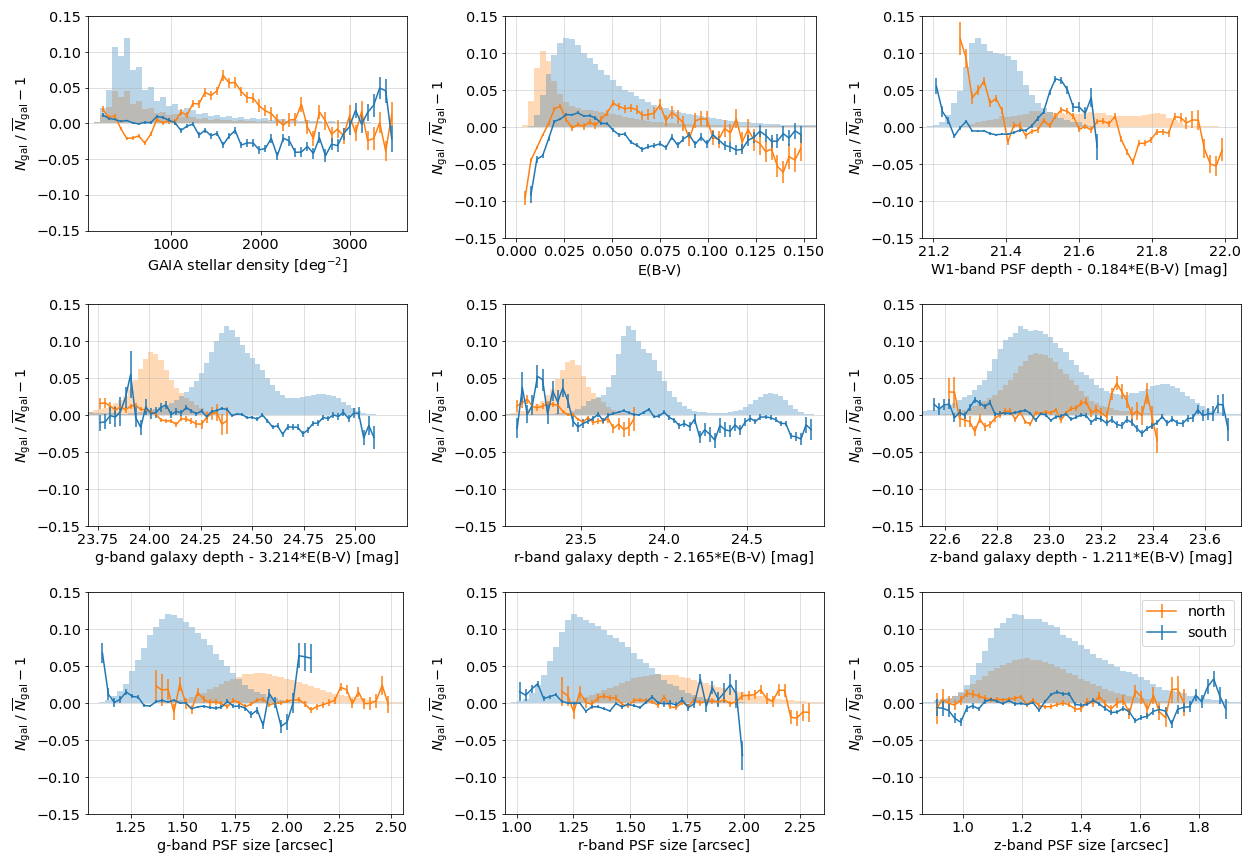

In [13]:
# BGS_ANY
Image('/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/no_decals_des_separation/bgs_any_minobs_1_maskbits_113/systematics_bgs_any_512_ebv_corr.png')

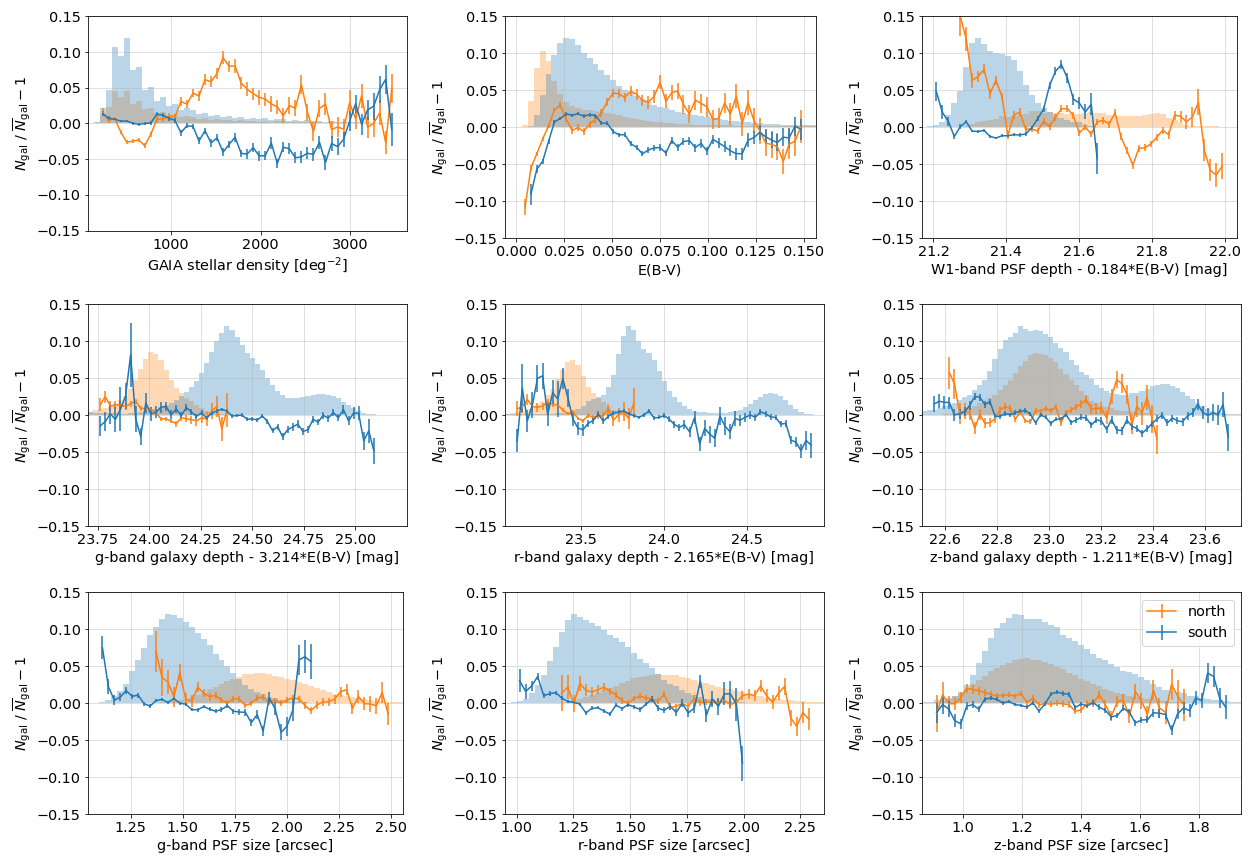

In [14]:
# BGS_BRIGHT
Image('/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/no_decals_des_separation/bgs_bright_minobs_1_maskbits_113/systematics_bgs_bright_512_ebv_corr.png')

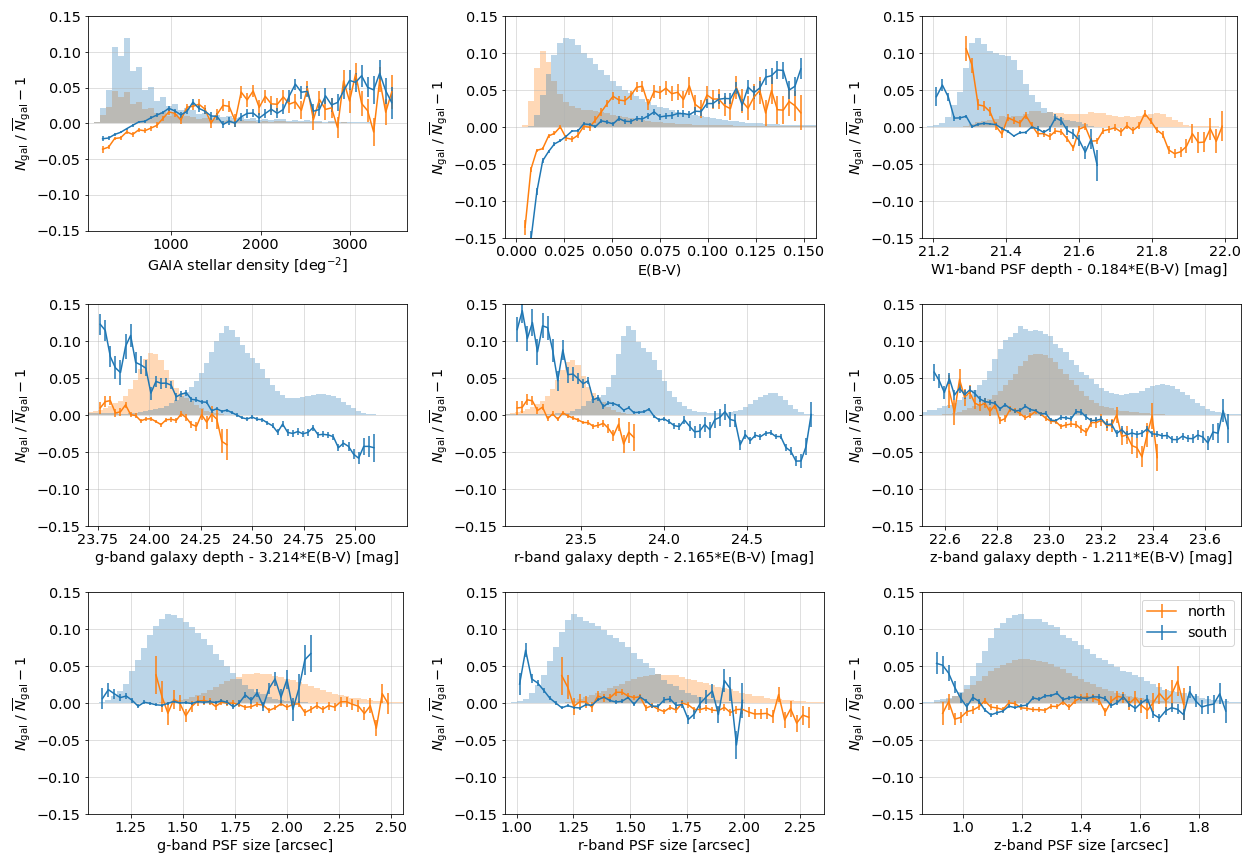

In [15]:
# LRG
Image('/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/no_decals_des_separation/lrg_minobs_1_maskbits_189111213/systematics_lrg_512_ebv_corr.png')

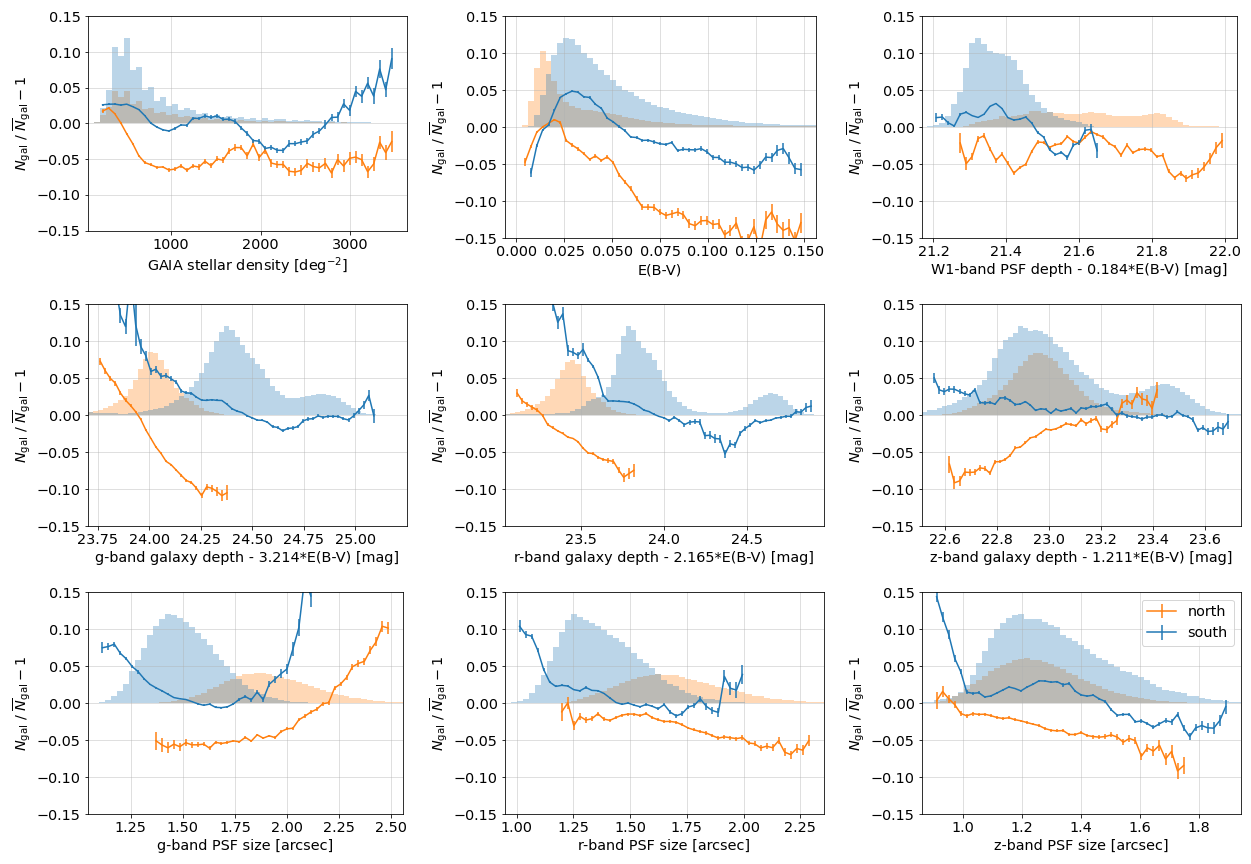

In [16]:
# ELG
Image('/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/no_decals_des_separation/elg_minobs_1_maskbits_1111213/systematics_elg_512_ebv_corr.png')

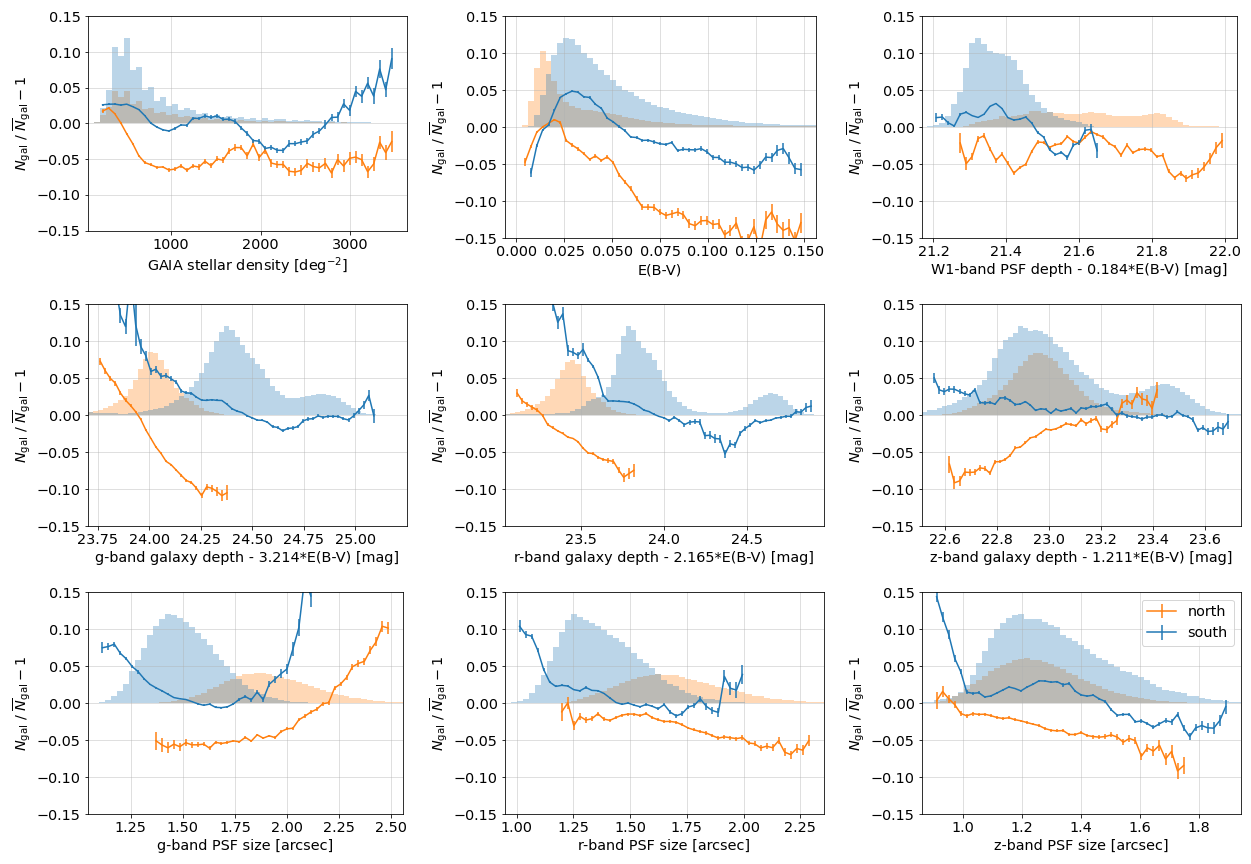

In [17]:
# QSO
Image('/Users/rongpu/Documents/Work/DESI/imaging_systematics/density_trends/1.0.0/resolve/no_decals_des_separation/elg_minobs_1_maskbits_1111213/systematics_elg_512_ebv_corr.png')